In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, f1_score

walk_forward_adm1 = pd.read_parquet("/data/big/fmoss/data/model_output/merged/adm1_grouped/2_stage_model_walk_forward_hr.parquet") 
loocv_adm1 = pd.read_parquet("/data/big/fmoss/data/model_output/merged/adm1_grouped/2_stage_model_loocv.parquet") 

# Add date to loocv
date_map = walk_forward_adm1[["DisNo.", "GID_1", "date"]].drop_duplicates()
loocv_adm1 = loocv_adm1.merge(date_map, on=["DisNo.", "GID_1"], how="right")
loocv_adm1["date"] = pd.to_datetime(loocv_adm1["date"], errors="coerce")
loocv_adm1["year"] = loocv_adm1["date"].dt.year
loocv_adm1["month"] = loocv_adm1["date"].dt.month
loocv_adm1["day"] = loocv_adm1["date"].dt.day

# Extract year and month for walk-forward (already has date)
walk_forward_adm1["date"] = pd.to_datetime(walk_forward_adm1["date"], errors="coerce")
walk_forward_adm1["year"] = walk_forward_adm1["date"].dt.year
walk_forward_adm1["month"] = walk_forward_adm1["date"].dt.month
walk_forward_adm1["day"] = walk_forward_adm1["date"].dt.day


def compute_cumulative_metrics_general(df, threshold=0, resolution="year", from_year=2000):
    """
    Compute cumulative precision/recall/f1 at different temporal resolutions:
    resolution can be "year", "month", or "day" (year+month+day).
    """
    df = df.copy()
    df = df[df.year >= from_year]
    df["reported_bin"] = (df["reported"] > threshold).astype(int)
    df["pred_bin"] = (df["predicted"] > threshold).astype(int)
    
    # Define temporal column for aggregation
    if resolution == "year":
        df["time_index"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-01-01")
    elif resolution == "month":
        df["time_index"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" +
                                          df["month"].fillna(1).astype(int).astype(str) + "-01")
    elif resolution == "day":
        df["time_index"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" +
                                          df["month"].fillna(1).astype(int).astype(str) + "-" +
                                          df["day"].fillna(1).astype(int).astype(str))
    else:
        raise ValueError("resolution must be one of ['year','month','day']")
    
    # Sort by time_index
    df = df.sort_values("time_index")

    # Unique time points
    time_points = df["time_index"].dropna().unique()

    results = []
    for t in time_points:
        df_cum = df[df["time_index"] <= t]
        if df_cum["reported_bin"].sum() == 0:
            precision = np.nan
        else:
            precision = precision_score(df_cum["reported_bin"], df_cum["pred_bin"], zero_division=0)

        recall = recall_score(df_cum["reported_bin"], df_cum["pred_bin"], zero_division=0)
        f1 = f1_score(df_cum["reported_bin"], df_cum["pred_bin"], zero_division=0)

        results.append({
            "time_index": t,
            "year": t.year,
            "month": t.month,
            "day": t.day,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(results).dropna(subset="year")

# -------- Walk-forward --------
metrics_t0_walk_forward_yearly  = compute_cumulative_metrics_general(walk_forward_adm1, threshold=0,  resolution="year", from_year=2012)
metrics_t15_walk_forward_yearly = compute_cumulative_metrics_general(walk_forward_adm1, threshold=15, resolution="year", from_year=2012)

metrics_t0_walk_forward_monthly  = compute_cumulative_metrics_general(walk_forward_adm1, threshold=0,  resolution="month")
metrics_t15_walk_forward_monthly = compute_cumulative_metrics_general(walk_forward_adm1, threshold=15, resolution="month")

metrics_t0_walk_forward_daily  = compute_cumulative_metrics_general(walk_forward_adm1, threshold=0,  resolution="day")
metrics_t15_walk_forward_daily = compute_cumulative_metrics_general(walk_forward_adm1, threshold=15, resolution="day")

# -------- LOOCV --------
metrics_t0_loocv_yearly  = compute_cumulative_metrics_general(loocv_adm1, threshold=0,  resolution="year", from_year=2012)
metrics_t15_loocv_yearly = compute_cumulative_metrics_general(loocv_adm1, threshold=15, resolution="year", from_year=2012)

metrics_t0_loocv_monthly  = compute_cumulative_metrics_general(loocv_adm1, threshold=0,  resolution="month")
metrics_t15_loocv_monthly = compute_cumulative_metrics_general(loocv_adm1, threshold=15, resolution="month")

metrics_t0_loocv_daily  = compute_cumulative_metrics_general(loocv_adm1, threshold=0,  resolution="day")
metrics_t15_loocv_daily = compute_cumulative_metrics_general(loocv_adm1, threshold=15, resolution="day")


# cutoff
metrics_t0_walk_forward_yearly = metrics_t0_walk_forward_yearly[metrics_t0_walk_forward_yearly.year > 2000]
metrics_t15_walk_forward_yearly = metrics_t15_walk_forward_yearly[metrics_t15_walk_forward_yearly.year > 2000]

metrics_t0_loocv_yearly = metrics_t0_loocv_yearly[metrics_t0_loocv_yearly.year > 2000]
metrics_t15_loocv_yearly = metrics_t15_loocv_yearly[metrics_t15_loocv_yearly.year > 2000]

In [2]:
def compute_non_cumulative_metrics(df, threshold=0, resolution="year"):
    df = df.copy()
    df["reported_bin"] = (df["reported"] > threshold).astype(int)
    df["pred_bin"] = (df["predicted"] > threshold).astype(int)
    
    # Define temporal column for aggregation
    if resolution == "year":
        group_cols = ["year"]
    elif resolution == "month":
        group_cols = ["year", "month"]
    elif resolution == "day":
        group_cols = ["year", "month", "day"]
    else:
        raise ValueError("resolution must be one of ['year','month','day']")
    
    results = []
    grouped = df.groupby(group_cols)
    
    for time_vals, group in grouped:
        # Unwrap tuple if it's length 1 (year-only case)
        if isinstance(time_vals, tuple):
            if len(time_vals) == 1:
                time_vals = time_vals[0]

        precision = precision_score(group["reported_bin"], group["pred_bin"], zero_division=0) \
                    if group["reported_bin"].sum() > 0 else np.nan
        recall    = recall_score(group["reported_bin"], group["pred_bin"], zero_division=0)
        f1        = f1_score(group["reported_bin"], group["pred_bin"], zero_division=0)

        # Assign year/month/day based on resolution
        if resolution == "year":
            year = time_vals
            month = 1
            day = 1
        elif resolution == "month":
            year, month = time_vals
            day = 1
        else:
            year, month, day = time_vals
        
        results.append({
            "time_index": pd.to_datetime(f"{year}-{month:02d}-{day:02d}"),
            "year": year,
            "month": month,
            "day": day,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })
    
    return pd.DataFrame(results).sort_values("time_index").reset_index(drop=True)

resolutions = ["year", "month", "day"]
thresholds = [0, 15]

metrics_nf_walk = {}
metrics_nf_loocv = {}

for res in resolutions:
    for t in thresholds:
        # Walk-forward
        metrics_nf_walk[f"{res}_t{t}"] = compute_non_cumulative_metrics(
            walk_forward_adm1, threshold=t, resolution=res
        )
        # LOOCV
        metrics_nf_loocv[f"{res}_t{t}"] = compute_non_cumulative_metrics(
            loocv_adm1, threshold=t, resolution=res
        )

Plots


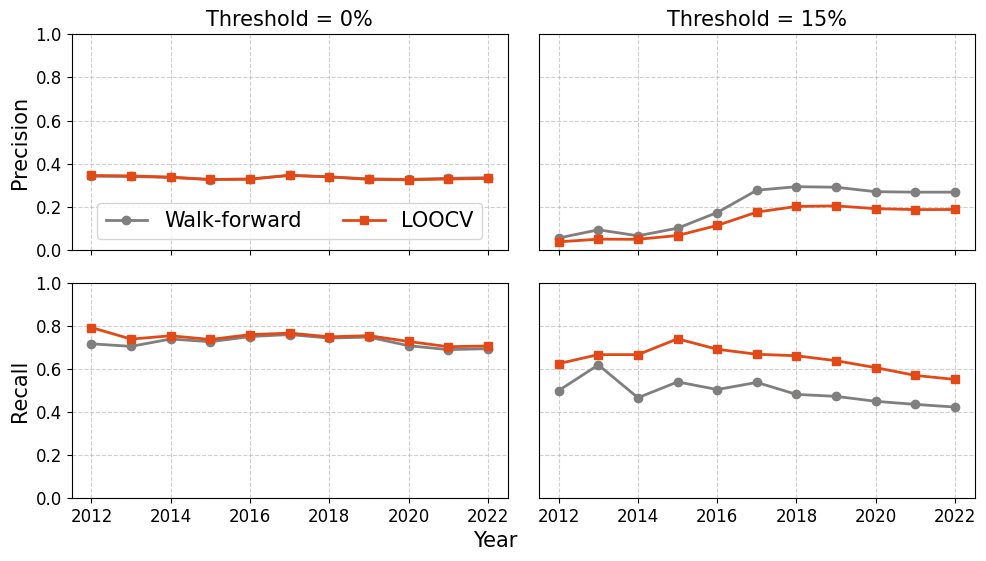

In [8]:
# Custom colors
color_walkforward = "#817F7D"
color_loocv = "#E24916"

fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)

# -------- TOP ROW: PRECISION --------
# Threshold = 0%
ax[0, 0].plot(metrics_t0_walk_forward_yearly["year"], metrics_t0_walk_forward_yearly["precision"],
              color=color_walkforward, marker="o", linestyle="-", label="Walk-forward", linewidth=2)
ax[0, 0].plot(metrics_t0_loocv_yearly["year"], metrics_t0_loocv_yearly["precision"],
              color=color_loocv, marker="s", linestyle="-", label="LOOCV", linewidth=2)
ax[0, 0].set_title("Threshold = 0%", fontsize=15)
ax[0, 0].set_ylabel("Precision", fontsize=15)
ax[0, 0].set_ylim([0, 1])
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(labelsize=12)

# Threshold = 15%
ax[0, 1].plot(metrics_t15_walk_forward_yearly["year"], metrics_t15_walk_forward_yearly["precision"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=2)
ax[0, 1].plot(metrics_t15_loocv_yearly["year"], metrics_t15_loocv_yearly["precision"],
              color=color_loocv, marker="s", linestyle="-", linewidth=2)
ax[0, 1].set_title("Threshold = 15%", fontsize=15)
ax[0, 1].set_ylim([0, 1])
ax[0, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)

# -------- BOTTOM ROW: RECALL --------
# Threshold = 0%
ax[1, 0].plot(metrics_t0_walk_forward_yearly["year"], metrics_t0_walk_forward_yearly["recall"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=2)
ax[1, 0].plot(metrics_t0_loocv_yearly["year"], metrics_t0_loocv_yearly["recall"],
              color=color_loocv, marker="s", linestyle="-", linewidth=2)
ax[1, 0].set_ylabel("Recall", fontsize=15)
ax[1, 0].set_ylim([0, 1])
ax[1, 0].grid(True, linestyle='--', alpha=0.6)
ax[1, 0].tick_params(labelsize=12)

# Threshold = 15%
ax[1, 1].plot(metrics_t15_walk_forward_yearly["year"], metrics_t15_walk_forward_yearly["recall"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=2)
ax[1, 1].plot(metrics_t15_loocv_yearly["year"], metrics_t15_loocv_yearly["recall"],
              color=color_loocv, marker="s", linestyle="-", linewidth=2)
ax[1, 1].set_ylim([0, 1])
ax[1, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

# -------- COMMON X-LABEL --------
fig.text(0.5, 0.04, "Year", ha='center', fontsize=15)

# # -------- SINGLE LEGEND ABOVE PLOTS --------
# lines, labels = ax[0, 0].get_legend_handles_labels()
# fig.legend(lines, labels, loc="upper center", ncol=2, fontsize=15, bbox_to_anchor=(0.5, 1.02))

# -------- LEGEND ON TOP-LEFT SUBPLOT ONLY --------
ax[0, 0].legend(loc="lower center", ncol=2, fontsize=15, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/walk_forward_vs_loocv_yearly_last_ten_years.png", 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.2)
plt.show()


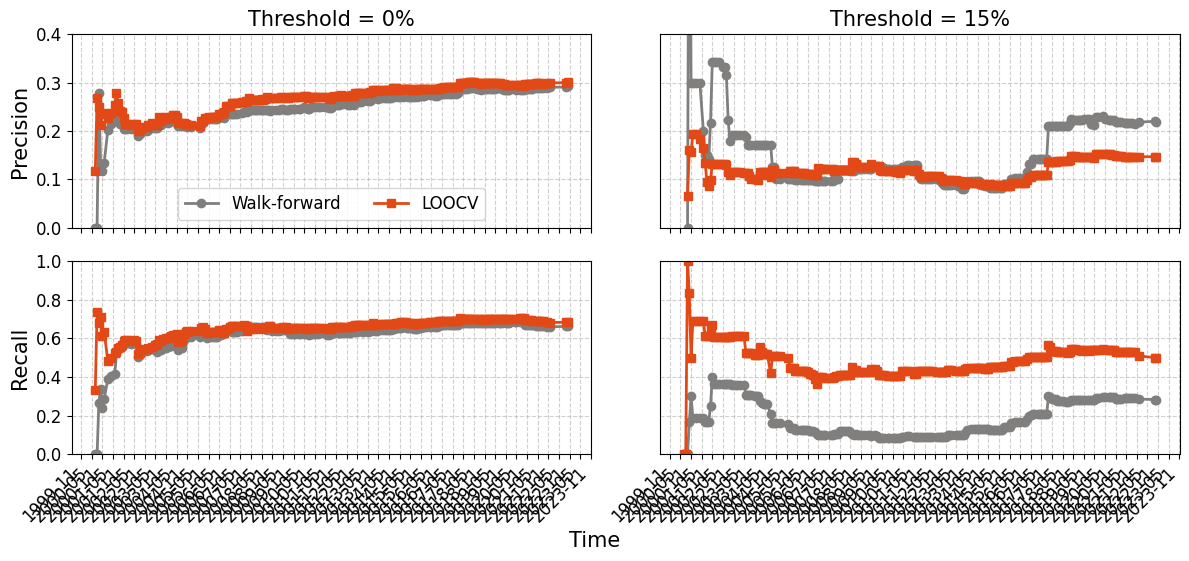

In [33]:
import matplotlib.dates as mdates

# Custom colors
color_walkforward = "#817F7D"
color_loocv = "#E24916"

# Prepare date_plot for all monthly metrics
for df in [metrics_t0_walk_forward_monthly, metrics_t15_walk_forward_monthly,
           metrics_t0_loocv_monthly, metrics_t15_loocv_monthly]:
    df["year"] = df["year"].fillna(2000).astype(int)
    df["month"] = df["month"].fillna(1).astype(int)
    df["date_plot"] = pd.to_datetime(df["year"].astype(str) + "-" +
                                     df["month"].astype(str) + "-01")

fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=False)

# -------- TOP ROW: PRECISION --------
ax[0, 0].plot(metrics_t0_walk_forward_monthly["date_plot"], metrics_t0_walk_forward_monthly["precision"],
              color=color_walkforward, marker="o", linestyle="-", label="Walk-forward", linewidth=2)
ax[0, 0].plot(metrics_t0_loocv_monthly["date_plot"], metrics_t0_loocv_monthly["precision"],
              color=color_loocv, marker="s", linestyle="-", label="LOOCV", linewidth=2)
ax[0, 0].set_title("Threshold = 0%", fontsize=15)
ax[0, 0].set_ylabel("Precision", fontsize=15)
ax[0, 0].set_ylim([0, 0.4])
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(labelsize=12)
ax[0, 0].legend(loc="lower center", ncol=2, fontsize=12, frameon=True)

ax[0, 1].plot(metrics_t15_walk_forward_monthly["date_plot"], metrics_t15_walk_forward_monthly["precision"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=2)
ax[0, 1].plot(metrics_t15_loocv_monthly["date_plot"], metrics_t15_loocv_monthly["precision"],
              color=color_loocv, marker="s", linestyle="-", linewidth=2)
ax[0, 1].set_title("Threshold = 15%", fontsize=15)
ax[0, 1].set_ylim([0, 0.4])
ax[0, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)

# -------- BOTTOM ROW: RECALL --------
ax[1, 0].plot(metrics_t0_walk_forward_monthly["date_plot"], metrics_t0_walk_forward_monthly["recall"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=2)
ax[1, 0].plot(metrics_t0_loocv_monthly["date_plot"], metrics_t0_loocv_monthly["recall"],
              color=color_loocv, marker="s", linestyle="-", linewidth=2)
ax[1, 0].set_ylabel("Recall", fontsize=15)
ax[1, 0].set_ylim([0, 1])
ax[1, 0].grid(True, linestyle='--', alpha=0.6)
ax[1, 0].tick_params(labelsize=12)

ax[1, 1].plot(metrics_t15_walk_forward_monthly["date_plot"], metrics_t15_walk_forward_monthly["recall"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=2)
ax[1, 1].plot(metrics_t15_loocv_monthly["date_plot"], metrics_t15_loocv_monthly["recall"],
              color=color_loocv, marker="s", linestyle="-", linewidth=2)
ax[1, 1].set_ylim([0, 1])
ax[1, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

# -------- COMMON X-LABEL --------
fig.text(0.5, 0.04, "Time", ha='center', fontsize=15)

# Format x-axis for monthly data
for a in ax[1, :]:
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(a.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/walk_forward_vs_loocv_monthly.png", 
            dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()


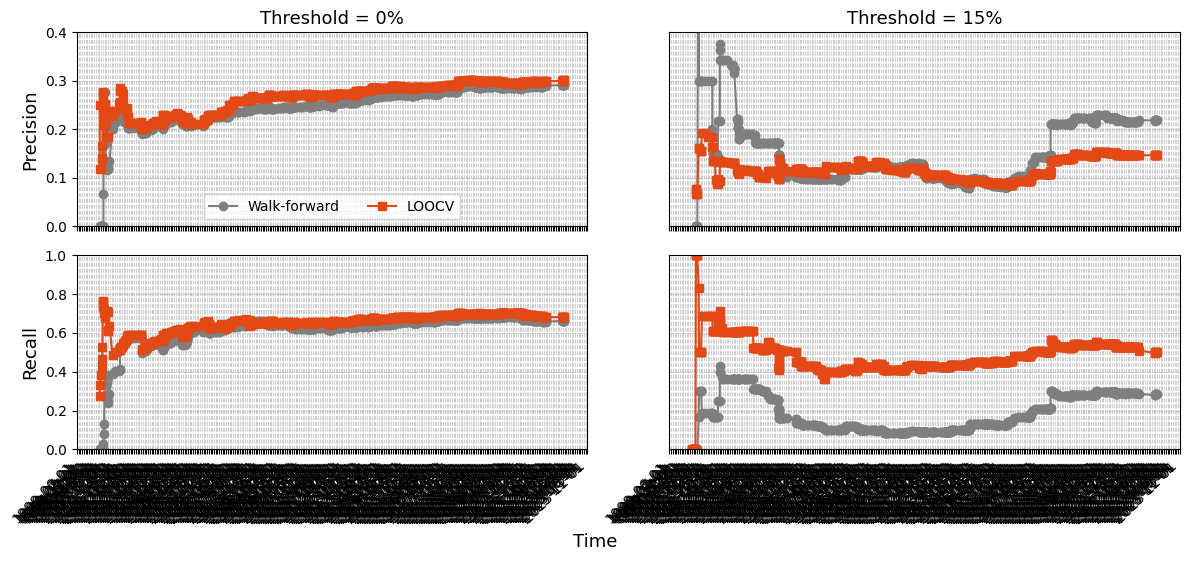

In [34]:
import matplotlib.dates as mdates

# Custom colors
color_walkforward = "#817F7D"
color_loocv = "#E24916"

# Prepare date_plot for daily metrics
for df in [metrics_t0_walk_forward_daily, metrics_t15_walk_forward_daily,
           metrics_t0_loocv_daily, metrics_t15_loocv_daily]:
    # Fill missing year/month/day
    df["year"]  = df["year"].fillna(2000).astype(int)
    df["month"] = df["month"].fillna(1).astype(int)
    df["day"]   = df["day"].fillna(1).astype(int)

    # Create datetime column
    df["date_plot"] = pd.to_datetime(
        df["year"].astype(str) + "-" +
        df["month"].astype(str) + "-" +
        df["day"].astype(str)
    )

fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=False)

# -------- TOP ROW: PRECISION --------
ax[0, 0].plot(metrics_t0_walk_forward_daily["date_plot"], metrics_t0_walk_forward_daily["precision"],
              color=color_walkforward, marker="o", linestyle="-", label="Walk-forward", linewidth=1.5)
ax[0, 0].plot(metrics_t0_loocv_daily["date_plot"], metrics_t0_loocv_daily["precision"],
              color=color_loocv, marker="s", linestyle="-", label="LOOCV", linewidth=1.5)
ax[0, 0].set_title("Threshold = 0%", fontsize=13)
ax[0, 0].set_ylabel("Precision", fontsize=13)
ax[0, 0].set_ylim([0, 0.4])
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(labelsize=10)
ax[0, 0].legend(loc="lower center", ncol=2, fontsize=10, frameon=True)

ax[0, 1].plot(metrics_t15_walk_forward_daily["date_plot"], metrics_t15_walk_forward_daily["precision"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=1.5)
ax[0, 1].plot(metrics_t15_loocv_daily["date_plot"], metrics_t15_loocv_daily["precision"],
              color=color_loocv, marker="s", linestyle="-", linewidth=1.5)
ax[0, 1].set_title("Threshold = 15%", fontsize=13)
ax[0, 1].set_ylim([0, 0.4])
ax[0, 1].tick_params(left=False, labelleft=False, labelsize=10)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)

# -------- BOTTOM ROW: RECALL --------
ax[1, 0].plot(metrics_t0_walk_forward_daily["date_plot"], metrics_t0_walk_forward_daily["recall"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=1.5)
ax[1, 0].plot(metrics_t0_loocv_daily["date_plot"], metrics_t0_loocv_daily["recall"],
              color=color_loocv, marker="s", linestyle="-", linewidth=1.5)
ax[1, 0].set_ylabel("Recall", fontsize=13)
ax[1, 0].set_ylim([0, 1])
ax[1, 0].grid(True, linestyle='--', alpha=0.6)
ax[1, 0].tick_params(labelsize=10)

ax[1, 1].plot(metrics_t15_walk_forward_daily["date_plot"], metrics_t15_walk_forward_daily["recall"],
              color=color_walkforward, marker="o", linestyle="-", linewidth=1.5)
ax[1, 1].plot(metrics_t15_loocv_daily["date_plot"], metrics_t15_loocv_daily["recall"],
              color=color_loocv, marker="s", linestyle="-", linewidth=1.5)
ax[1, 1].set_ylim([0, 1])
ax[1, 1].tick_params(left=False, labelleft=False, labelsize=10)
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

# -------- COMMON X-LABEL --------
fig.text(0.5, 0.04, "Time", ha='center', fontsize=13)

# Format x-axis nicely for daily data
for a in ax[1, :]:
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # major ticks every month
    plt.setp(a.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/walk_forward_vs_loocv_daily.png", 
            dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()


In [3]:
# Count unique events per year and compute cumulative sum
events_per_year = loocv_adm1.groupby("year")["DisNo."].nunique()
cumsum_events = events_per_year.cumsum()

In [48]:
len(loocv_adm1["DisNo."].unique())

779

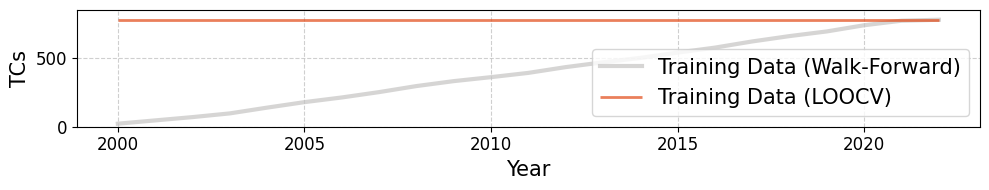

In [5]:
# Count unique events per year and compute cumulative sum
events_per_year = loocv_adm1.groupby("year")["DisNo."].nunique()
cumsum_events = events_per_year.cumsum()

# Plot cumulative sum
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(cumsum_events.index, cumsum_events.values, 
        marker="", linestyle="-", color="#C5C4C3", linewidth=3, alpha=0.7,
        label="Training Data (Walk-Forward)")

y_val = len(loocv_adm1["DisNo."].unique())
ax.hlines(
    y=y_val,
    xmin=2000,
    xmax=2022,
    linestyle="-",
    color="#E24916",
    linewidth=2,
    label="Training Data (LOOCV)",
    alpha=0.7
)
# # Markers
# years = np.arange(2000, 2023)

# ax.plot(
#     years,
#     np.full(len(years), y_val),
#     marker="o",
#     linestyle="None",
#     color="#E24916",
#     markersize=6,
#     alpha=0.7
# )

ax.set_ylabel("TCs", fontsize=15)
ax.set_xlabel("Year", fontsize=15)  # no x-label
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc="lower right", fontsize=15, frameon=True)
ax.set_ylim([0, 850])
plt.tight_layout()

plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/walk_forward_vs_loocv_2.png", 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.2)

plt.show()


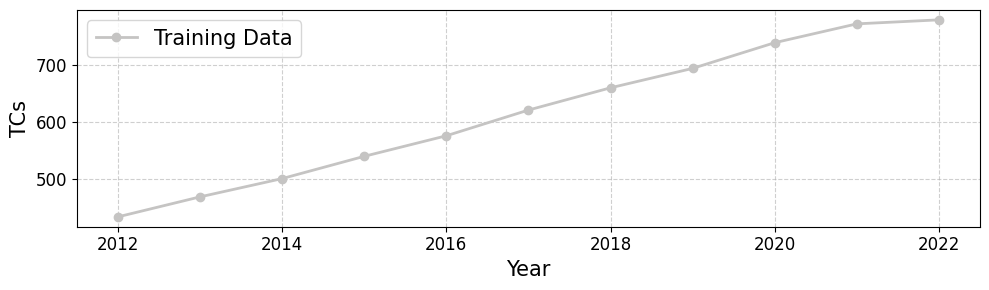

In [3]:
# Count unique events per year and compute cumulative sum
events_per_year = loocv_adm1.groupby("year")["DisNo."].nunique()
cumsum_events = events_per_year.cumsum()

# Keep only years >= 2012 for plotting, but cumulative sum includes previous years
cumsum_events_plot = cumsum_events[cumsum_events.index >= 2012]

# Plot cumulative sum
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(
    cumsum_events_plot.index, 
    cumsum_events_plot.values, 
    marker="o", 
    linestyle="-", 
    color="#C5C4C3", 
    linewidth=2, 
    label="Training Data"
)
ax.set_ylabel("TCs", fontsize=15)
ax.set_xlabel("Year", fontsize=15)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc="upper left", fontsize=15, frameon=True)
plt.tight_layout()

plt.savefig(
    "/home/fmoss/GLOBAL MODEL/local_files/walk_forward_vs_loocv_3.png", 
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.2
)

plt.show()


Non additive plots

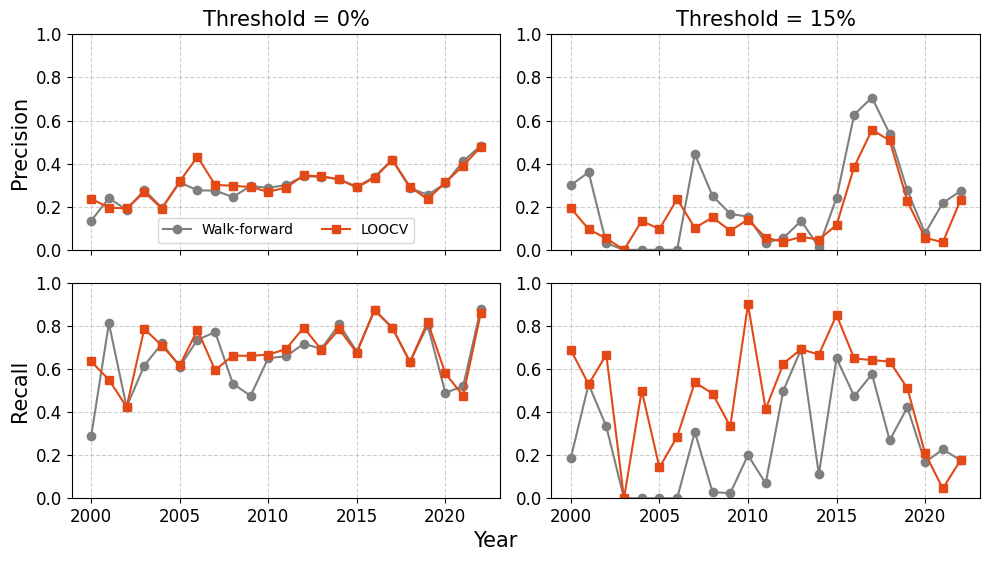

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_non_cumulative_metrics(metrics_nf_walk, metrics_nf_loocv, resolution="day", thresholds=[0, 15], save_path=None):
    """
    Plot 2x2 non-cumulative precision/recall metrics for walk-forward vs LOOCV.
    
    metrics_nf_walk, metrics_nf_loocv: dict of DataFrames with keys like "day_t0", "day_t15"
    resolution: "year", "month", or "day"
    thresholds: list of thresholds to plot
    save_path: optional path to save figure
    """
    
    color_walkforward = "#817F7D"
    color_loocv = "#E24916"
    
    fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)
    
    for i, t in enumerate(thresholds):
        key = f"{resolution}_t{t}"
        df_walk = metrics_nf_walk[key].copy()
        df_loocv = metrics_nf_loocv[key].copy()
        
        # Ensure year/month/day for plotting
        for df in [df_walk, df_loocv]:
            df["year"]  = df.get("year", 2000).fillna(2000).astype(int)
            if resolution in ["month", "day"]:
                df["month"] = df.get("month", 1).fillna(1).astype(int)
            if resolution == "day":
                df["day"] = df.get("day", 1).fillna(1).astype(int)
            
            # Build date_plot
            if resolution == "year":
                df["date_plot"] = pd.to_datetime(df["year"].astype(str) + "-01-01")
            elif resolution == "month":
                df["date_plot"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")
            else:
                df["date_plot"] = pd.to_datetime(df["year"].astype(str) + "-" +
                                                 df["month"].astype(str) + "-" +
                                                 df["day"].astype(str))
            df.sort_values("date_plot", inplace=True)
        
        # Top row: Precision
        ax[0, i].plot(df_walk["date_plot"], df_walk["precision"],
                      color=color_walkforward, marker="o", linestyle="-", label="Walk-forward", linewidth=1.5)
        ax[0, i].plot(df_loocv["date_plot"], df_loocv["precision"],
                      color=color_loocv, marker="s", linestyle="-", label="LOOCV", linewidth=1.5)
        ax[0, i].set_title(f"Threshold = {t}%", fontsize=15)
        ax[0, 0].set_ylabel("Precision", fontsize=15)
        ax[0, i].set_ylim([0, 1])
        ax[0, i].grid(True, linestyle='--', alpha=0.6)
        ax[0, i].tick_params(labelsize=12)
        if i == 0:
            ax[0, i].legend(loc="lower center", ncol=2, fontsize=10, frameon=True)
        
        # Bottom row: Recall
        ax[1, i].plot(df_walk["date_plot"], df_walk["recall"],
                      color=color_walkforward, marker="o", linestyle="-", linewidth=1.5)
        ax[1, i].plot(df_loocv["date_plot"], df_loocv["recall"],
                      color=color_loocv, marker="s", linestyle="-", linewidth=1.5)
        ax[1, 0].set_ylabel("Recall", fontsize=15)
        ax[1, i].set_ylim([0, 1])
        ax[1, i].grid(True, linestyle='--', alpha=0.6)
        ax[1, i].tick_params(labelsize=12)
    
    # Common X-label
    fig.text(0.5, 0.04, "Year", ha='center', fontsize=15)
    
    # Format x-axis nicely
    for a in ax[1, :]:
        if resolution == "year":
            a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            a.xaxis.set_major_locator(mdates.YearLocator(base=5))
        elif resolution == "month":
            a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
            a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        else:  # day
            a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
            a.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        plt.setp(a.get_xticklabels(), rotation=0, ha="center")
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.2)
    
    plt.show()

# # Daily non-cumulative
# plot_non_cumulative_metrics(metrics_nf_walk, metrics_nf_loocv, resolution="day",
#                             thresholds=[0,15], save_path="walk_forward_vs_loocv_daily_nf.png")


# Yearly non-cumulative
plot_non_cumulative_metrics(metrics_nf_walk, metrics_nf_loocv, resolution="year",
                            thresholds=[0,15], save_path="walk_forward_vs_loocv_yearly_nf.png")


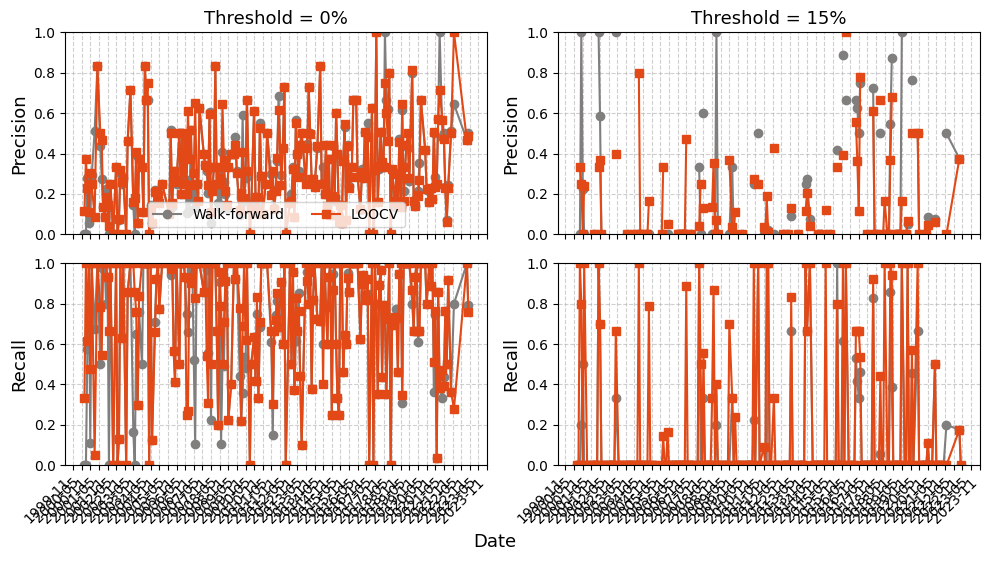

In [52]:
# Monthly non-cumulative
plot_non_cumulative_metrics(metrics_nf_walk, metrics_nf_loocv, resolution="month",
                            thresholds=[0,15], save_path="walk_forward_vs_loocv_monthly_nf.png")


Rolling window

In [ ]:
def compute_rolling_metrics(df, threshold=0, window_years=5, resolution="year", from_year=2000):
    """
    Compute precision/recall/f1 using a rolling time window.

    df: dataframe with columns ['reported', 'predicted', 'year','month','day']
    threshold: decision threshold for binarization
    window_years: size of rolling window in years
    resolution: 'year', 'month', or 'day'
    """
    df = df.copy()
    df = df[df.year >= from_year]

    # Binarize
    df["reported_bin"] = (df["reported"] > threshold).astype(int)
    df["pred_bin"] = (df["predicted"] > threshold).astype(int)

    # Time index
    if resolution == "year":
        df["time_index"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-01-01")

    elif resolution == "month":
        df["time_index"] = pd.to_datetime(
            df["year"].astype(int).astype(str) + "-" +
            df["month"].fillna(1).astype(int).astype(str) + "-01"
        )

    elif resolution == "day":
        df["time_index"] = pd.to_datetime(
            df["year"].astype(int).astype(str) + "-" +
            df["month"].fillna(1).astype(int).astype(str) + "-" +
            df["day"].fillna(1).astype(int).astype(str)
        )

    else:
        raise ValueError("resolution must be one of ['year','month','day']")

    df = df.sort_values("time_index")
    time_points = df["time_index"].dropna().unique()

    results = []

    for t in time_points:

        # --- rolling window start ---
        t_start = t - pd.DateOffset(years=window_years)
        df_window = df[(df["time_index"] > t_start) & (df["time_index"] <= t)]
        print(len(df_window))
        if len(df_window) == 0:
            continue

        # Compute metrics
        if df_window["reported_bin"].sum() == 0:
            precision = np.nan
        else:
            precision = precision_score(df_window["reported_bin"], df_window["pred_bin"], zero_division=0)

        recall = recall_score(df_window["reported_bin"], df_window["pred_bin"], zero_division=0)
        f1 = f1_score(df_window["reported_bin"], df_window["pred_bin"], zero_division=0)

        results.append({
            "time_index": t,
            "year": t.year,
            "month": t.month,
            "day": t.day,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(results)

metrics_roll5_walk_t0 = compute_rolling_metrics(
    walk_forward_adm1, threshold=0, window_years=5, resolution="month", from_year=2005
)

metrics_roll5_loocv_t0 = compute_rolling_metrics(
    loocv_adm1, threshold=0, window_years=5, resolution="month", from_year=2005
)

metrics_roll5_walk_t15 = compute_rolling_metrics(
    walk_forward_adm1, threshold=15, window_years=5, resolution="month", from_year=2005
)

metrics_roll5_loocv_t15 = compute_rolling_metrics(
    loocv_adm1, threshold=15, window_years=5, resolution="month", from_year=2005
)

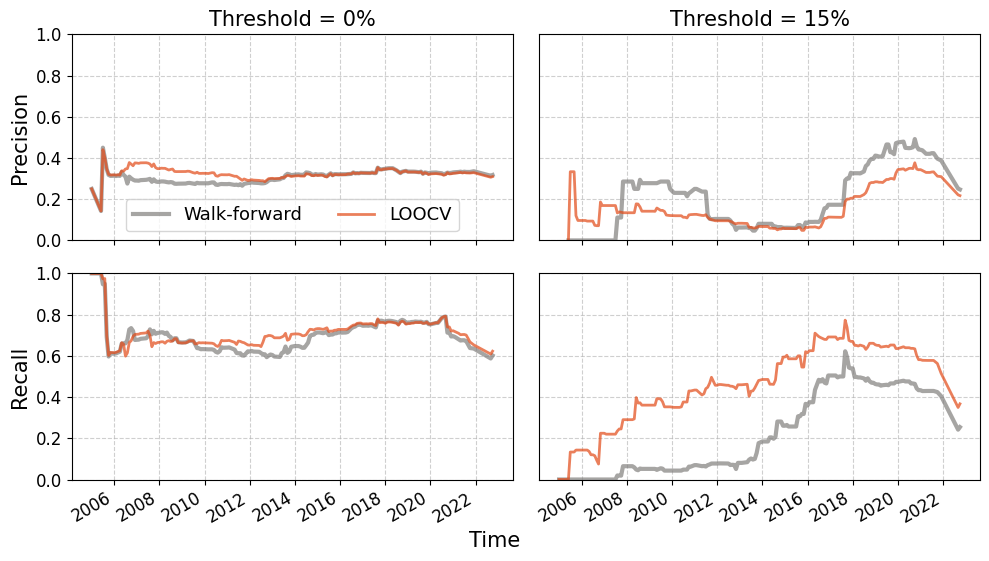

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Custom colors
color_walkforward = "#817F7D"
color_loocv = "#E24916"

fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)

# -------- TOP ROW: PRECISION --------
# Threshold = 0%
ax[0, 0].plot(metrics_roll5_walk_t0["time_index"], metrics_roll5_walk_t0["precision"],
              color=color_walkforward, linestyle="-", label="Walk-forward", linewidth=3, alpha=0.7)
ax[0, 0].plot(metrics_roll5_loocv_t0["time_index"], metrics_roll5_loocv_t0["precision"],
              color=color_loocv, linestyle="-", label="LOOCV", linewidth=2, alpha=0.7)
ax[0, 0].set_title("Threshold = 0%", fontsize=15)
ax[0, 0].set_ylabel("Precision", fontsize=15)
ax[0, 0].set_ylim([0, 1])
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(labelsize=12)

# Threshold = 15%
ax[0, 1].plot(metrics_roll5_walk_t15["time_index"], metrics_roll5_walk_t15["precision"],
              color=color_walkforward, linestyle="-", linewidth=3, alpha=0.7)
ax[0, 1].plot(metrics_roll5_loocv_t15["time_index"], metrics_roll5_loocv_t15["precision"],
              color=color_loocv, linestyle="-", linewidth=2, alpha=0.7)
ax[0, 1].set_title("Threshold = 15%", fontsize=15)
ax[0, 1].set_ylim([0, 1])
ax[0, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)

# -------- BOTTOM ROW: RECALL --------
# Threshold = 0%
ax[1, 0].plot(metrics_roll5_walk_t0["time_index"], metrics_roll5_walk_t0["recall"],
              color=color_walkforward, linestyle="-", linewidth=3, alpha=0.7)
ax[1, 0].plot(metrics_roll5_loocv_t0["time_index"], metrics_roll5_loocv_t0["recall"],
              color=color_loocv, linestyle="-", linewidth=2, alpha=0.7)
ax[1, 0].set_ylabel("Recall", fontsize=15)
ax[1, 0].set_ylim([0, 1])
ax[1, 0].grid(True, linestyle='--', alpha=0.6)
ax[1, 0].tick_params(labelsize=12)

# Threshold = 15%
ax[1, 1].plot(metrics_roll5_walk_t15["time_index"], metrics_roll5_walk_t15["recall"],
              color=color_walkforward, linestyle="-", linewidth=3, alpha=0.7)
ax[1, 1].plot(metrics_roll5_loocv_t15["time_index"], metrics_roll5_loocv_t15["recall"],
              color=color_loocv, linestyle="-", linewidth=2, alpha=0.7)
ax[1, 1].set_ylim([0, 1])
ax[1, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

# -------- COMMON X-LABEL --------
fig.text(0.5, 0.04, "Time", ha='center', fontsize=15)

# -------- LEGEND ON TOP-LEFT SUBPLOT ONLY --------
ax[0, 0].legend(loc="lower center", ncol=2, fontsize=13, frameon=True)

# -------- Format x-axis for dates (show every 2 years) --------
for a in ax[1, :]:  # bottom row
    a.xaxis.set_major_locator(mdates.YearLocator(2))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout(rect=[0, 0.05, 1, 0.96])

# plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/walk_forward_vs_loocv_rolling5_time_index.png", 
#             dpi=300, 
#             bbox_inches='tight', 
#             pad_inches=0.2)

plt.show()


In [34]:
def compute_rolling_metrics_with_bootstrap(df, threshold=0, resolution="year", window_size=5, n_boot=30, ci=0.95, seed=None, from_year=2005):
    """
    Compute rolling metrics with bootstrapped confidence intervals.
    """
    import numpy as np
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    rng = np.random.default_rng(seed)
    
    df = df.copy()
    df = df[df.year >= from_year]
    df["reported_bin"] = (df["reported"] > threshold).astype(int)
    df["pred_bin"] = (df["predicted"] > threshold).astype(int)
    
    # create time_index like in compute_cumulative_metrics_general
    if resolution == "year":
        df["time_index"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-01-01")
    elif resolution == "month":
        df["time_index"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" +
                                          df["month"].fillna(1).astype(int).astype(str) + "-01")
    elif resolution == "day":
        df["time_index"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" +
                                          df["month"].fillna(1).astype(int).astype(str) + "-" +
                                          df["day"].fillna(1).astype(int).astype(str))
    else:
        raise ValueError("resolution must be one of ['year','month','day']")
    
    df = df.sort_values("time_index")
    time_points = df["time_index"].dropna().unique()
    
    results = []
    
    for t in time_points:
        # rolling window: keep last 'window_size' years
        window_start = t - pd.DateOffset(years=window_size)
        df_window = df[(df["time_index"] > window_start) & (df["time_index"] <= t)]
        n = len(df_window)
        if n == 0:
            continue
        
        # bootstrap
        prec_boot, rec_boot, f1_boot = [], [], []
        for _ in range(n_boot):
            sampled = df_window.sample(n=n, replace=True, random_state=rng.integers(0, 1e9))
            if sampled["reported_bin"].sum() == 0:
                prec_boot.append(np.nan)
            else:
                prec_boot.append(precision_score(sampled["reported_bin"], sampled["pred_bin"], zero_division=0))
            rec_boot.append(recall_score(sampled["reported_bin"], sampled["pred_bin"], zero_division=0))
            f1_boot.append(f1_score(sampled["reported_bin"], sampled["pred_bin"], zero_division=0))
        
        # confidence intervals
        def ci_bounds(arr, ci):
            arr = np.array(arr)
            arr = arr[~np.isnan(arr)]
            if len(arr) == 0:
                return np.nan, np.nan
            lower = np.percentile(arr, (1 - ci)/2 * 100)
            upper = np.percentile(arr, (1 + ci)/2 * 100)
            return lower, upper
        
        p_lower, p_upper = ci_bounds(prec_boot, ci)
        r_lower, r_upper = ci_bounds(rec_boot, ci)
        f_lower, f_upper = ci_bounds(f1_boot, ci)
        
        results.append({
            "time_index": t,
            "precision_mean": np.nanmean(prec_boot),
            "precision_lower": p_lower,
            "precision_upper": p_upper,
            "recall_mean": np.nanmean(rec_boot),
            "recall_lower": r_lower,
            "recall_upper": r_upper,
            "f1_mean": np.nanmean(f1_boot),
            "f1_lower": f_lower,
            "f1_upper": f_upper
        })
    
    return pd.DataFrame(results)

metrics_roll5_walk_t0 = compute_rolling_metrics_with_bootstrap(
    walk_forward_adm1, threshold=0, window_size=5, resolution="month", from_year=2000
)

metrics_roll5_loocv_t0 = compute_rolling_metrics_with_bootstrap(
    loocv_adm1, threshold=0, window_size=5, resolution="month", from_year=2000
)

metrics_roll5_walk_t15 = compute_rolling_metrics_with_bootstrap(
    walk_forward_adm1, threshold=15, window_size=5, resolution="month", from_year=2000
)

metrics_roll5_loocv_t15 = compute_rolling_metrics_with_bootstrap(
    loocv_adm1, threshold=15, window_size=5, resolution="month", from_year=2000
)

/tmp/ipykernel_3689902/3453086383.py:68: RuntimeWarning: Mean of empty slice
  "precision_mean": np.nanmean(prec_boot),
/tmp/ipykernel_3689902/3453086383.py:68: RuntimeWarning: Mean of empty slice
  "precision_mean": np.nanmean(prec_boot),
/tmp/ipykernel_3689902/3453086383.py:68: RuntimeWarning: Mean of empty slice
  "precision_mean": np.nanmean(prec_boot),
/tmp/ipykernel_3689902/3453086383.py:68: RuntimeWarning: Mean of empty slice
  "precision_mean": np.nanmean(prec_boot),


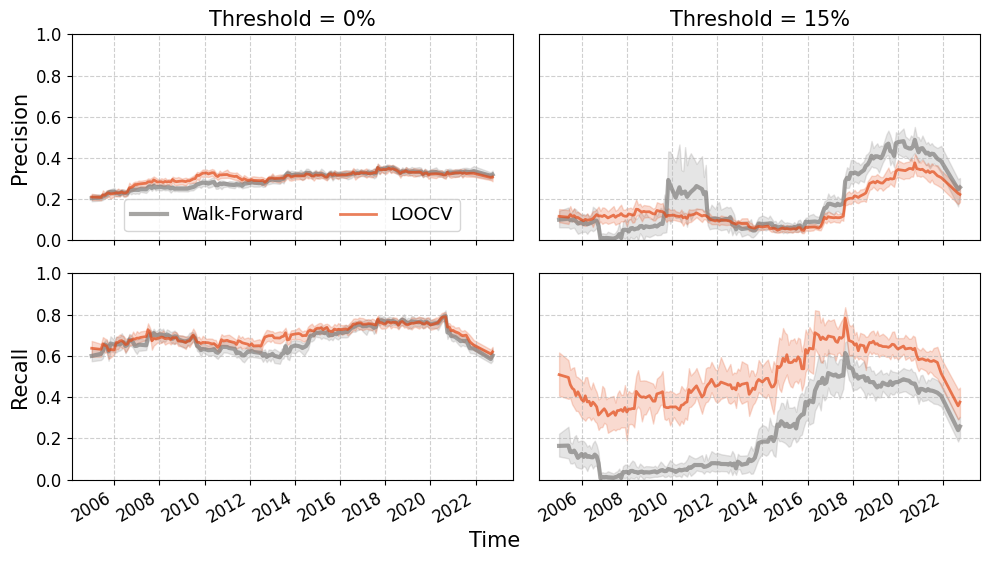

In [67]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Custom colors
color_walkforward = "#817F7D"
color_loocv = "#E24916"

fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)

# Subset or copy rolling metrics starting from 2005
metrics_boot_walk_t0 = metrics_roll5_walk_t0[metrics_roll5_walk_t0.time_index >= "2005-01-01"].copy()
metrics_boot_loocv_t0 = metrics_roll5_loocv_t0[metrics_roll5_loocv_t0.time_index >= "2005-01-01"].copy()
metrics_boot_walk_t15 = metrics_roll5_walk_t15[metrics_roll5_walk_t15.time_index >= "2005-01-01"].copy()
metrics_boot_loocv_t15 = metrics_roll5_loocv_t15[metrics_roll5_loocv_t15.time_index >= "2005-01-01"].copy()


# -------- TOP ROW: PRECISION --------
# Threshold = 0%
ax[0, 0].plot(metrics_boot_walk_t0["time_index"], metrics_boot_walk_t0["precision_mean"],
              color=color_walkforward, linestyle="-", label="Walk-Forward", linewidth=3, alpha=0.7)
ax[0, 0].fill_between(metrics_boot_walk_t0["time_index"], 
                      metrics_boot_walk_t0["precision_lower"], 
                      metrics_boot_walk_t0["precision_upper"],
                      color=color_walkforward, alpha=0.2)

ax[0, 0].plot(metrics_boot_loocv_t0["time_index"], metrics_boot_loocv_t0["precision_mean"],
              color=color_loocv, linestyle="-", label="LOOCV", linewidth=2, alpha=0.7)
ax[0, 0].fill_between(metrics_boot_loocv_t0["time_index"], 
                      metrics_boot_loocv_t0["precision_lower"], 
                      metrics_boot_loocv_t0["precision_upper"],
                      color=color_loocv, alpha=0.2)

ax[0, 0].set_title("Threshold = 0%", fontsize=15)
ax[0, 0].set_ylabel("Precision", fontsize=15)
ax[0, 0].set_ylim([0, 1])
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(labelsize=12)
ax[0, 0].legend(loc="lower center", ncol=2, fontsize=13, frameon=True)

# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch
# from matplotlib.legend_handler import HandlerTuple

# # Create a tuple of (line, shaded patch) as a proxy for legend
# walk_proxy = (Line2D([0], [0], color=color_walkforward, linewidth=3),
#               Patch(facecolor=color_walkforward, alpha=0.2, edgecolor='none'))

# loocv_proxy = (Line2D([0], [0], color=color_loocv, linewidth=2),
#                Patch(facecolor=color_loocv, alpha=0.2, edgecolor='none'))

# # Add legend with HandlerTuple to combine line + shaded patch
# ax[0, 0].legend(
#     handles=[walk_proxy, loocv_proxy],
#     labels=["Walk-forward", "LOOCV"],
#     handler_map={tuple: HandlerTuple(ndivide=None)},
#     loc="lower center",
#     ncol=2,
#     fontsize=13,
#     frameon=True
# )


# Threshold = 15%
ax[0, 1].plot(metrics_boot_walk_t15["time_index"], metrics_boot_walk_t15["precision_mean"],
              color=color_walkforward, linestyle="-", linewidth=3, alpha=0.7)
ax[0, 1].fill_between(metrics_boot_walk_t15["time_index"], 
                      metrics_boot_walk_t15["precision_lower"], 
                      metrics_boot_walk_t15["precision_upper"],
                      color=color_walkforward, alpha=0.2)

ax[0, 1].plot(metrics_boot_loocv_t15["time_index"], metrics_boot_loocv_t15["precision_mean"],
              color=color_loocv, linestyle="-", linewidth=2, alpha=0.7)
ax[0, 1].fill_between(metrics_boot_loocv_t15["time_index"], 
                      metrics_boot_loocv_t15["precision_lower"], 
                      metrics_boot_loocv_t15["precision_upper"],
                      color=color_loocv, alpha=0.2)

ax[0, 1].set_title("Threshold = 15%", fontsize=15)
ax[0, 1].set_ylim([0, 1])
ax[0, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)

# -------- BOTTOM ROW: RECALL --------
# Threshold = 0%
ax[1, 0].plot(metrics_boot_walk_t0["time_index"], metrics_boot_walk_t0["recall_mean"],
              color=color_walkforward, linestyle="-", linewidth=3, alpha=0.7)
ax[1, 0].fill_between(metrics_boot_walk_t0["time_index"], 
                      metrics_boot_walk_t0["recall_lower"], 
                      metrics_boot_walk_t0["recall_upper"],
                      color=color_walkforward, alpha=0.2)

ax[1, 0].plot(metrics_boot_loocv_t0["time_index"], metrics_boot_loocv_t0["recall_mean"],
              color=color_loocv, linestyle="-", linewidth=2, alpha=0.7)
ax[1, 0].fill_between(metrics_boot_loocv_t0["time_index"], 
                      metrics_boot_loocv_t0["recall_lower"], 
                      metrics_boot_loocv_t0["recall_upper"],
                      color=color_loocv, alpha=0.2)

ax[1, 0].set_ylabel("Recall", fontsize=15)
ax[1, 0].set_ylim([0, 1])
ax[1, 0].grid(True, linestyle='--', alpha=0.6)
ax[1, 0].tick_params(labelsize=12)

# Threshold = 15%
ax[1, 1].plot(metrics_boot_walk_t15["time_index"], metrics_boot_walk_t15["recall_mean"],
              color=color_walkforward, linestyle="-", linewidth=3, alpha=0.7)
ax[1, 1].fill_between(metrics_boot_walk_t15["time_index"], 
                      metrics_boot_walk_t15["recall_lower"], 
                      metrics_boot_walk_t15["recall_upper"],
                      color=color_walkforward, alpha=0.2)

ax[1, 1].plot(metrics_boot_loocv_t15["time_index"], metrics_boot_loocv_t15["recall_mean"],
              color=color_loocv, linestyle="-", linewidth=2, alpha=0.7)
ax[1, 1].fill_between(metrics_boot_loocv_t15["time_index"],
                      metrics_boot_loocv_t15["recall_lower"],
                      metrics_boot_loocv_t15["recall_upper"],
                      color=color_loocv, alpha=0.2)

ax[1, 1].set_ylim([0, 1])
ax[1, 1].tick_params(left=False, labelleft=False, labelsize=12)
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

# -------- COMMON X-LABEL --------
fig.text(0.5, 0.04, "Time", ha='center', fontsize=15)

# -------- Format x-axis for dates (show every 2 years) --------
for a in ax[1, :]:
    a.xaxis.set_major_locator(mdates.YearLocator(2))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/walk_forward_vs_loocv_rolling_5_years.png", 
            dpi=300, 
            bbox_inches='tight', 
            pad_inches=0.2)
plt.show()
